## Sharing data for Z

In [1]:
%reload_ext autoreload
%autoreload 2

### 1. Decode
These files, due to size, are written to disk rather than inserted into the database. The database keeps the file path only.

These files are uploaded to Dropbox for sharing with Mattar Lab.


#### How to load decode:

In [10]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def select_subset_helper(xr_ob,plottimes,target_len = 0,epsilon = 0):
    if xr_ob is None:
        return None
    xr_ob = xr_ob.sel(
        time=xr_ob.time[
            np.logical_and(xr_ob.time>=plottimes[0],xr_ob.time<=plottimes[1])])
    if target_len > 0 and len(xr_ob.time) > 0:
        xr_ob2 = xr_ob.isel(time= slice(0,target_len))
        if (np.abs(xr_ob2.time[0]-plottimes[0])<=epsilon) and (np.abs(xr_ob2.time[-1]-plottimes[1])<=epsilon):
            return xr_ob2
        else:
            print("some missing position data")
            return xr_ob
        
    return xr_ob

In [3]:
# suppose this is the path to the decoding file
decoding_path = '/cumulus/shijie/recording_pilot/eliot/decoding/eliot20221022_.nwb_02_Seq2Session1_2Dheadspeed_above_4_andlowmua_result.nc'

posterior = xr.open_dataset(decoding_path)

In [4]:
posterior

<xarray.Dataset> Size: 8GB
Dimensions:            (time: 1094427, state: 2, position: 301)
Coordinates:
  * time               (time) float64 9MB 1.666e+09 1.666e+09 ... 1.666e+09
  * position           (position) float64 2kB 0.9938 2.981 4.969 ... 740.1 742.0
  * state              (state) object 16B 'Continuous' 'Uniform'
Data variables:
    likelihood         (time, state, position) float32 3GB ...
    causal_posterior   (time, state, position) float32 3GB ...
    acausal_posterior  (time, state, position) float32 3GB ...
Attributes:
    data_log_likelihood:  -493618.72

In [5]:
# just pick a snippet
t0 = posterior.time[10000].item()
plottimes = (t0, t0 + 5)

In [6]:
results_subset = select_subset_helper(posterior,plottimes)

# get posterior over position
posterior_position_subset=results_subset.acausal_posterior.sum(
            dim='state')

# get posterior over replay state
posterior_state_subset=results_subset.acausal_posterior.sum('position')

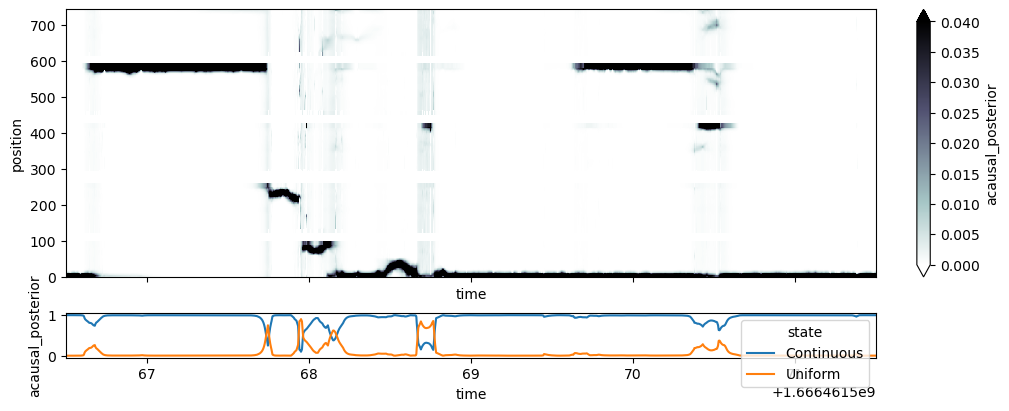

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True,
                             constrained_layout=True, gridspec_kw={"height_ratios": [3,0.5]},)

### plot posterior over position bins like this:
x_axis=np.arange(plottimes[0],plottimes[1],100)
posterior_position_subset.plot(
            x='time', y='position', ax=axes[0], rasterized=True, robust=True, cmap='bone_r', vmax = 0.04)

posterior_state_subset.plot(x='time',hue='state',ax=axes[1])

### 2. Ripple Times
The files are parsed ripple intervals along with parsed meta data. 

#### How to read in ripple files.

In [8]:
example_file_path = '/cumulus/shijie/recording_pilot/eliot/decoding/eliot20221026_.nwb_12_Seq2Session6_extended_ripple_times_with_decode.pkl'

In [11]:
pd.read_pickle(example_file_path)

,start_time,end_time,animal_location,trial_number,cont_intvl,frag_intvl,cont_intvl_replay,duration,mean_zscore,median_zscore,max_zscore,min_zscore,speed_at_start,speed_at_end,max_speed,min_speed,median_speed,mean_speed
1,1.666828e+09,1.666828e+09,well3,1,"[[1666827745.1132278, 1666827745.237228]]",[],[[3]],0.126,1.115132,0.988496,3.372495,0.004264,2.641671,1.543351,2.817758,1.543351,2.651575,2.456055
2,1.666828e+09,1.666828e+09,well3,1,"[[1666827749.709227, 1666827749.749227]]","[[1666827749.7512271, 1666827749.835227]]",[[]],0.128,1.307439,0.933281,3.968376,-0.370188,1.228227,0.637061,1.228227,0.637061,0.961912,0.952435
3,1.666828e+09,1.666828e+09,home,2,"[[1666827761.471225, 1666827761.495225], [1666...","[[1666827761.497225, 1666827761.541225], [1666...","[[4], []]",0.208,3.286753,1.425812,15.144457,-0.139818,0.087148,0.087147,0.087148,0.087147,0.087148,0.087148
4,1.666828e+09,1.666828e+09,home,2,"[[1666827763.555225, 1666827763.6892247], [166...","[[1666827763.6912246, 1666827763.7112248]]","[[2], []]",0.228,3.985009,2.134417,15.434016,-0.608413,0.087147,0.087148,0.087148,0.087147,0.087148,0.087148
5,1.666828e+09,1.666828e+09,home,2,"[[1666827764.4832246, 1666827764.6212244]]","[[1666827764.6232245, 1666827764.6592245]]",[[0]],0.177,3.622743,3.111217,9.030773,-0.594313,0.069378,0.465966,0.465966,0.059846,0.134086,0.183943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,1.666829e+09,1.666829e+09,home,79,"[[1666829233.6989677, 1666829233.726967]]",[],[[]],0.030,2.401296,2.401957,5.122905,0.039616,1.251554,1.274591,1.274591,1.251554,1.263163,1.263157
163,1.666829e+09,1.666829e+09,well4,80,"[[1666829262.0289624, 1666829262.0709624], [16...","[[1666829262.0729623, 1666829262.1389625]]","[[], []]",0.142,2.142099,1.899257,5.286023,-0.665691,0.665015,0.286815,0.665015,0.121598,0.269713,0.327716
164,1.666829e+09,1.666829e+09,well4,80,"[[1666829262.2689624, 1666829262.3029623], [16...","[[1666829262.3049624, 1666829262.3469625]]","[[2], []]",0.175,3.997990,1.566748,18.122904,-0.451863,1.055739,2.444845,2.468382,1.055739,1.972100,1.898153
165,1.666829e+09,1.666829e+09,well4,80,"[[1666829262.5449624, 1666829262.5709624], [16...","[[1666829262.5729623, 1666829262.6009624]]","[[4], [4]]",0.121,2.122208,1.402144,8.359696,-0.797617,1.041857,1.791472,1.791472,0.461460,0.825474,0.956913


### 3. Animal location and Unsorted Spiking Multi-unit Activities

For record keeping, here is the code Shijie used to query from the database and copied data to the folder to share with Mattar lab.

#### How to load 1d, 2d position data

- Animals run in the 2D maze. Its position data can be loaded as follows.

In [13]:
example_pos2d_path = '/cumulus/shijie/recording_pilot/lewis/decoding/lewis20240106_.nwb_06_Rev2Session3_2dposition.csv'
pos2d = pd.read_csv(example_pos2d_path)
pos2d

,time,head_position_x,head_position_y,head_orientation,head_velocity_x,head_velocity_y,head_speed
0,1.704573e+09,123.839286,93.964286,-2.592315,-9.569296,0.576683,9.586657
1,1.704573e+09,123.827381,93.980159,-2.594389,-9.479466,0.649112,9.501664
2,1.704573e+09,123.815476,93.996032,-2.596463,-9.390374,0.718082,9.417790
3,1.704573e+09,123.803571,94.011905,-2.598539,-9.302005,0.783589,9.334951
4,1.704573e+09,123.791667,94.027778,-2.600614,-9.214341,0.845627,9.253063
...,...,...,...,...,...,...,...
729048,1.704575e+09,182.315476,50.940476,-1.894745,-2.075888,-3.034557,3.676663
729049,1.704575e+09,182.305556,50.944444,-1.894600,-2.001946,-3.011426,3.616141
729050,1.704575e+09,182.295635,50.948413,-1.894456,-1.927443,-2.989465,3.556956
729051,1.704575e+09,182.285714,50.952381,-1.894311,-1.852386,-2.968677,3.499197


- However, to aid analyses, the 2D environment is reduced a 1D environment mostly projected along the maze tracks.
Home arm -> track_segment_id = 0

Arm 1 -> track_segment_id = 6

Arm 2 -> track_segment_id = 7

Arm 3 -> track_segment_id = 8

Arm 4 -> track_segment_id = 9

Center Platform -> track_segment_id = 5

Start and end 1D coordinates for each track_segment:

{0: array([0, 57.63896252]),

 6: array([165.66041604, 252.64353221]),
 
 7: array([331.10211383, 418.29227956]),
 
 8: array([496.49241045, 583.18763812]),
 
 9: array([657.72023142, 743.03215907])}

#### How to load unsorted multi-unit activity

In [14]:
# how to load 
example_marks_path = '/cumulus/shijie/recording_pilot/lewis/decoding/lewis20240106_.nwb_06_Rev2Session3_marks.nc'
marks = xr.load_dataset(example_marks_path)
marks

<xarray.Dataset> Size: 507MB
Dimensions:                        (time: 729053, marks: 4, electrodes: 43)
Coordinates:
  * time                           (time) float64 6MB 1.705e+09 ... 1.705e+09
  * electrodes                     (electrodes) int32 172B 0 1 7 8 ... 58 61 62
  * marks                          (marks) object 32B 'amplitude_0000' ... 'a...
Data variables:
    __xarray_dataarray_variable__  (time, marks, electrodes) float32 502MB na...

### 4. Sorted units from select sessions
Data are from select sessions from the following days:

In [ ]:
list_of_days_animals = {}

animal = 'eliot'
list_of_days_animals[animal] = ['20221018','20221019','20221021','20221022','20221023','20221024']


animal = "lewis"
list_of_days_animals[animal] = ["20240107", "20240108","20240109","20240110","20240113"]#["20240107", "20240108","20240109",	"20240110","20240113"]


bad_sessions = [('eliot', '20221019', '10_Seq2Session5'),
                ('lewis', '20240108', '06_Rev2Session3'),
                ('lewis', '20240108', '08_Rev2Session4'),
               ('lewis', '20240113', '02_Rev2Session1')] # these sessions have incomplete number of sorted tetrodes

#### How to load spiking data

In [16]:
example_spiking_path = '/cumulus/shijie/MattarLab/sorted_spikes/eliot20221018_.nwb_02_Seq2Session1_sorted_units.pkl'
df = pd.read_pickle(example_spiking_path)

In [17]:
df

spike_times  \
sort_group_id unit_id                                                      
0             3        [1666121994.8492334, 1666121995.008767, 166612...   
2             2        [1666122043.0108392, 1666122072.6725967, 16661...   
              3        [1666121995.689601, 1666121995.7517343, 166612...   
              4        [1666121996.3506348, 1666122002.0962057, 16661...   
              5        [1666122005.631276, 1666122014.0333824, 166612...   
...                                                                  ...   
30            7        [1666122006.4768763, 1666122007.3133771, 16661...   
31            2        [1666121992.522098, 1666121992.546565, 1666121...   
              3        [1666121996.0639677, 1666121996.4035347, 16661...   
              5        [1666121992.7040985, 1666121992.8236985, 16661...   
              7        [1666122002.6159732, 1666122002.64884, 1666122...   

                          unit_type  \
sort_group_id unit_id                 
0             3           pyramidal   
2             2           pyramidal   
              3           pyramidal   
              4           pyramidal   
              5           pyramidal   
...                             ...   
30            7           pyramidal   
31            2         interneuron   
              3           pyramidal   
              5        unclassified   
              7           pyramidal   

                                                             place_field  \
sort_group_id unit_id                                                      
0             3        [[nan, nan, nan, nan, nan, nan, nan, nan, nan,...   
2             2        [[nan, nan, nan, nan, nan, nan, nan, nan, nan,...   
              3        [[nan, nan, nan, nan, nan, nan, nan, nan, nan,...   
              4        [[nan, nan, nan, nan, nan, nan, nan, nan, nan,...   
              5        [[nan, nan, nan, nan, nan, nan, nan, nan, nan,...   
...                                                                  ...   
30            7        [[nan, nan, nan, nan, nan, nan, nan, nan, nan,...   
31            2        [[nan, nan, nan, nan, nan, nan, nan, nan, nan,...   
              3        [[nan, nan, nan, nan, nan, nan, nan, nan, nan,...   
              5        [[nan, nan, nan, nan, nan, nan, nan, nan, nan,...   
              7        [[nan, nan, nan, nan, nan, nan, nan, nan, nan,...   

                       peak_firing_rate  run_spike_count  still_spike_count  
sort_group_id unit_id                                                        
0             3               11.740238             1375               2165  
2             2                0.211344               10                153  
              3                6.322910              559                608  
              4               11.210232              635                766  
              5               15.647227              972               1173  
...                                 ...              ...                ...  
30            7               17.757712              260                302  
31            2               36.677255            17826              25538  
              3               24.317389              762               1276  
              5               44.134724            11472              21013  
              7                0.867234               19                162  

[112 rows x 6 columns]

In [18]:
### suppose we are interested unit (sort_group_id = 2, unit_id = 5)
(e,u) = (2,5) #electrode, unit

In [19]:
#### spike times
spike_times = df.loc[e,u].spike_times

In [20]:
#### unit type: either pyramidal or interneuron or unclassified
unit_type = df.loc[e,u].unit_type
print(f"Unit {(e,u)} is {unit_type}.")

Unit (2, 5) is pyramidal.


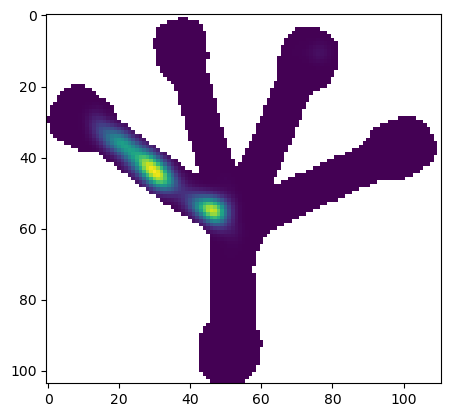

In [21]:
### place field
smoothed_placefield = df.loc[e,u].place_field
plt.imshow(smoothed_placefield)

## 5. Broad Band LFP

#### How to load

In [22]:
example_lfp_path = "/cumulus/shijie/MattarLab/lfp/eliot20221018_.nwb_lfp.nc"
lfp = xr.load_dataset(example_lfp_path)

In [23]:
lfp

<xarray.Dataset> Size: 980MB
Dimensions:    (time: 22277677)
Coordinates:
  * time       (time) float64 178MB 1.666e+09 1.666e+09 ... 1.666e+09 1.666e+09
Data variables: (12/18)
    channel0   (time) int16 45MB 48 121 143 204 263 277 ... 74 72 77 45 37 43
    channel1   (time) int16 45MB -10 -16 -4 53 99 111 ... 244 236 201 206 221
    channel2   (time) int16 45MB -4 -4 32 109 161 197 ... 108 106 121 100 84 84
    channel3   (time) int16 45MB -15 0 49 113 159 155 ... 9 39 39 -11 -15 -20
    channel4   (time) int16 45MB 101 212 208 248 289 294 ... -9 -19 -45 -55 -70
    channel5   (time) int16 45MB -53 -87 -3 68 92 62 62 ... 116 110 123 81 66 90
    ...         ...
    channel12  (time) int16 45MB 39 87 61 87 113 106 125 ... 77 52 21 -21 7 67
    channel13  (time) int16 45MB 131 258 215 227 248 ... -71 -95 -145 -126 -73
    channel14  (time) int16 45MB -47 -116 -108 -67 -32 ... 284 228 156 160 206
    channel15  (time) int16 45MB 65 116 80 115 146 147 ... 110 83 57 -3 21 84
    channel16  (time) int16 45MB 91 197 165 182 199 180 ... 103 60 27 -22 18 112
    channel17  (time) int16 45MB 84 186 153 166 182 174 ... 141 121 76 121 177

## 6. Ripple Band LFP

In [29]:
example_lfp_path = "/cumulus/shijie/MattarLab/ripple_lfp/lewis20240105_.nwb_ripple_lfp.nc"
ripple_lfp = xr.load_dataset(example_lfp_path)

In [30]:
ripple_lfp

<xarray.Dataset> Size: 51MB
Dimensions:    (time: 545898)
Coordinates:
  * time       (time) float64 4MB 1.704e+09 1.704e+09 ... 1.704e+09 1.704e+09
Data variables: (12/43)
    channel0   (time) int16 1MB 0 14 11 0 -11 -11 2 15 7 ... 0 1 0 -2 -1 1 1 0 0
    channel1   (time) int16 1MB -9 3 10 7 -1 -8 -7 2 9 ... 0 -1 0 1 -1 -4 -2 5 7
    channel2   (time) int16 1MB -1 13 10 -2 -10 -6 3 10 ... -5 -15 -7 6 11 5 -3
    channel3   (time) int16 1MB -22 -7 21 18 -12 -29 -4 28 ... -6 7 8 0 -7 -5 2
    channel4   (time) int16 1MB -22 3 26 14 -15 -25 -3 22 ... -5 0 3 -1 -4 0 3 2
    channel5   (time) int16 1MB -2 2 15 7 -19 -27 0 32 ... -11 -3 6 8 0 -7 -7 3
    ...         ...
    channel37  (time) int16 1MB 9 17 5 -10 -12 -2 5 6 3 ... -9 1 10 4 -8 -9 2 10
    channel38  (time) int16 1MB 14 20 6 -7 -11 -7 0 6 ... -11 -6 5 5 -3 -4 3 6
    channel39  (time) int16 1MB 1 20 18 1 -13 -17 -8 7 ... -4 6 9 -1 -10 -5 5 8
    channel40  (time) int16 1MB 7 -3 6 11 -7 -25 -10 19 ... -6 7 3 -10 -7 10 13
    channel41  (time) int16 1MB 3 10 14 2 -17 -19 2 21 ... -8 -1 8 6 -6 -9 0 9
    channel42  (time) int16 1MB -3 -6 13 25 -3 -40 -25 ... 2 16 6 -15 -16 6 18